In [1]:
"""Main script for training and evaluating Financial GAN."""

import os
from pathlib import Path

# Set the working directory to the root of the project
os.chdir(Path('..').resolve())  # Adjust this path as necessary

import torch
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from src.data.data_loading import (
    get_sp500_tickers, download_stock_data
)
from src.data.data_processing import (
    create_sequences,
    normalize_sequences,
    # denormalize_sequences
)
from src.training.trainer import Trainer
from src.evaluation.metrics import FinancialMetrics
from src.visualization.plots import SequenceVisualizer
from config import Config, setup_logging
import torch
import numpy as np
import matplotlib.pyplot as plt
from src.utils.paths import DIRS

import cProfile
import pstats
from pstats import SortKey
import time

import torch
import numpy as np

# Now you can use DIRS throughout your code
print("Project directories:")
for name, path in DIRS.items():
    print(f"- {name}: {path}")

setup_logging()
logger = logging.getLogger(__name__)

import numpy as np
from typing import Dict, Tuple

# sequence_length = 5
sequence_length = 30

config = Config()
# 1. Data Loading and Processing
print("\n=== Loading Data ===")
tickers = get_sp500_tickers(config)

# Setup profiler
profiler = cProfile.Profile()
profiler.enable()

# Time data loading
data_start = time.time()
# tickers = ['AAPL', 'MMM']
stock_data = download_stock_data(tickers, config)
# stock_data = {key: stock_data[key].head(7) for key in tickers}
# print(stock_data)

import numpy as np
import os

import h5py

# Define paths for HDF5 storage
sequences_hdf5_path = "data/sequences.h5"
normalized_hdf5_path = "data/normalized_data.h5"

import numpy as np
import h5py

valid_stocks, sequences, ticker_mapping = create_sequences(stock_data, sequence_length=sequence_length)

INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/data
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/checkpoints
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results/plots
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/results/models
INFO:src.utils.paths:Created directory: /Users/lucijagregov/Documents/gan_finance/logs
INFO:src.data.data_loading:Loaded data for 495 stocks


Project directories:
- data: /Users/lucijagregov/Documents/gan_finance/data
- results: /Users/lucijagregov/Documents/gan_finance/results
- checkpoints: /Users/lucijagregov/Documents/gan_finance/checkpoints
- plots: /Users/lucijagregov/Documents/gan_finance/results/plots
- models: /Users/lucijagregov/Documents/gan_finance/results/models
- logs: /Users/lucijagregov/Documents/gan_finance/logs

=== Loading Data ===
data/stock_data.pkl
After filtering: 494 valid stocks out of 495 total


Generating sequences: 100%|██████████| 494/494 [00:17<00:00, 27.73it/s]


In [2]:
import importlib
from src.data import data_processing
importlib.reload(data_processing)

from src.data.data_processing import normalize_with_progress, calculate_global_statistics

# feature_info = calculate_global_statistics(sequences, sample_size=100000)
normalized_data, normalization_params, feature_info = normalize_with_progress(sequences, window_size=1, sample_size=10000)
# normalized_data, normalization_params, feature_info = normalize_with_progress(sequences, window_size=1, sample_size=1)

Starting normalization of shape (358090, 30, 501)
Starting normalization. Input shape: (358090, 30, 501)


Normalizing: 100%|██████████| 358090/358090 [00:40<00:00, 8843.00it/s] 

Normalization completed in 41.69 seconds
Memory usage: 20531.05 MB


Input shapes - Original: (358090, 30, 501), Normalized: (358090, 30, 501)


Processing features: 100%|██████████| 5/5 [00:19<00:00,  3.85s/it]


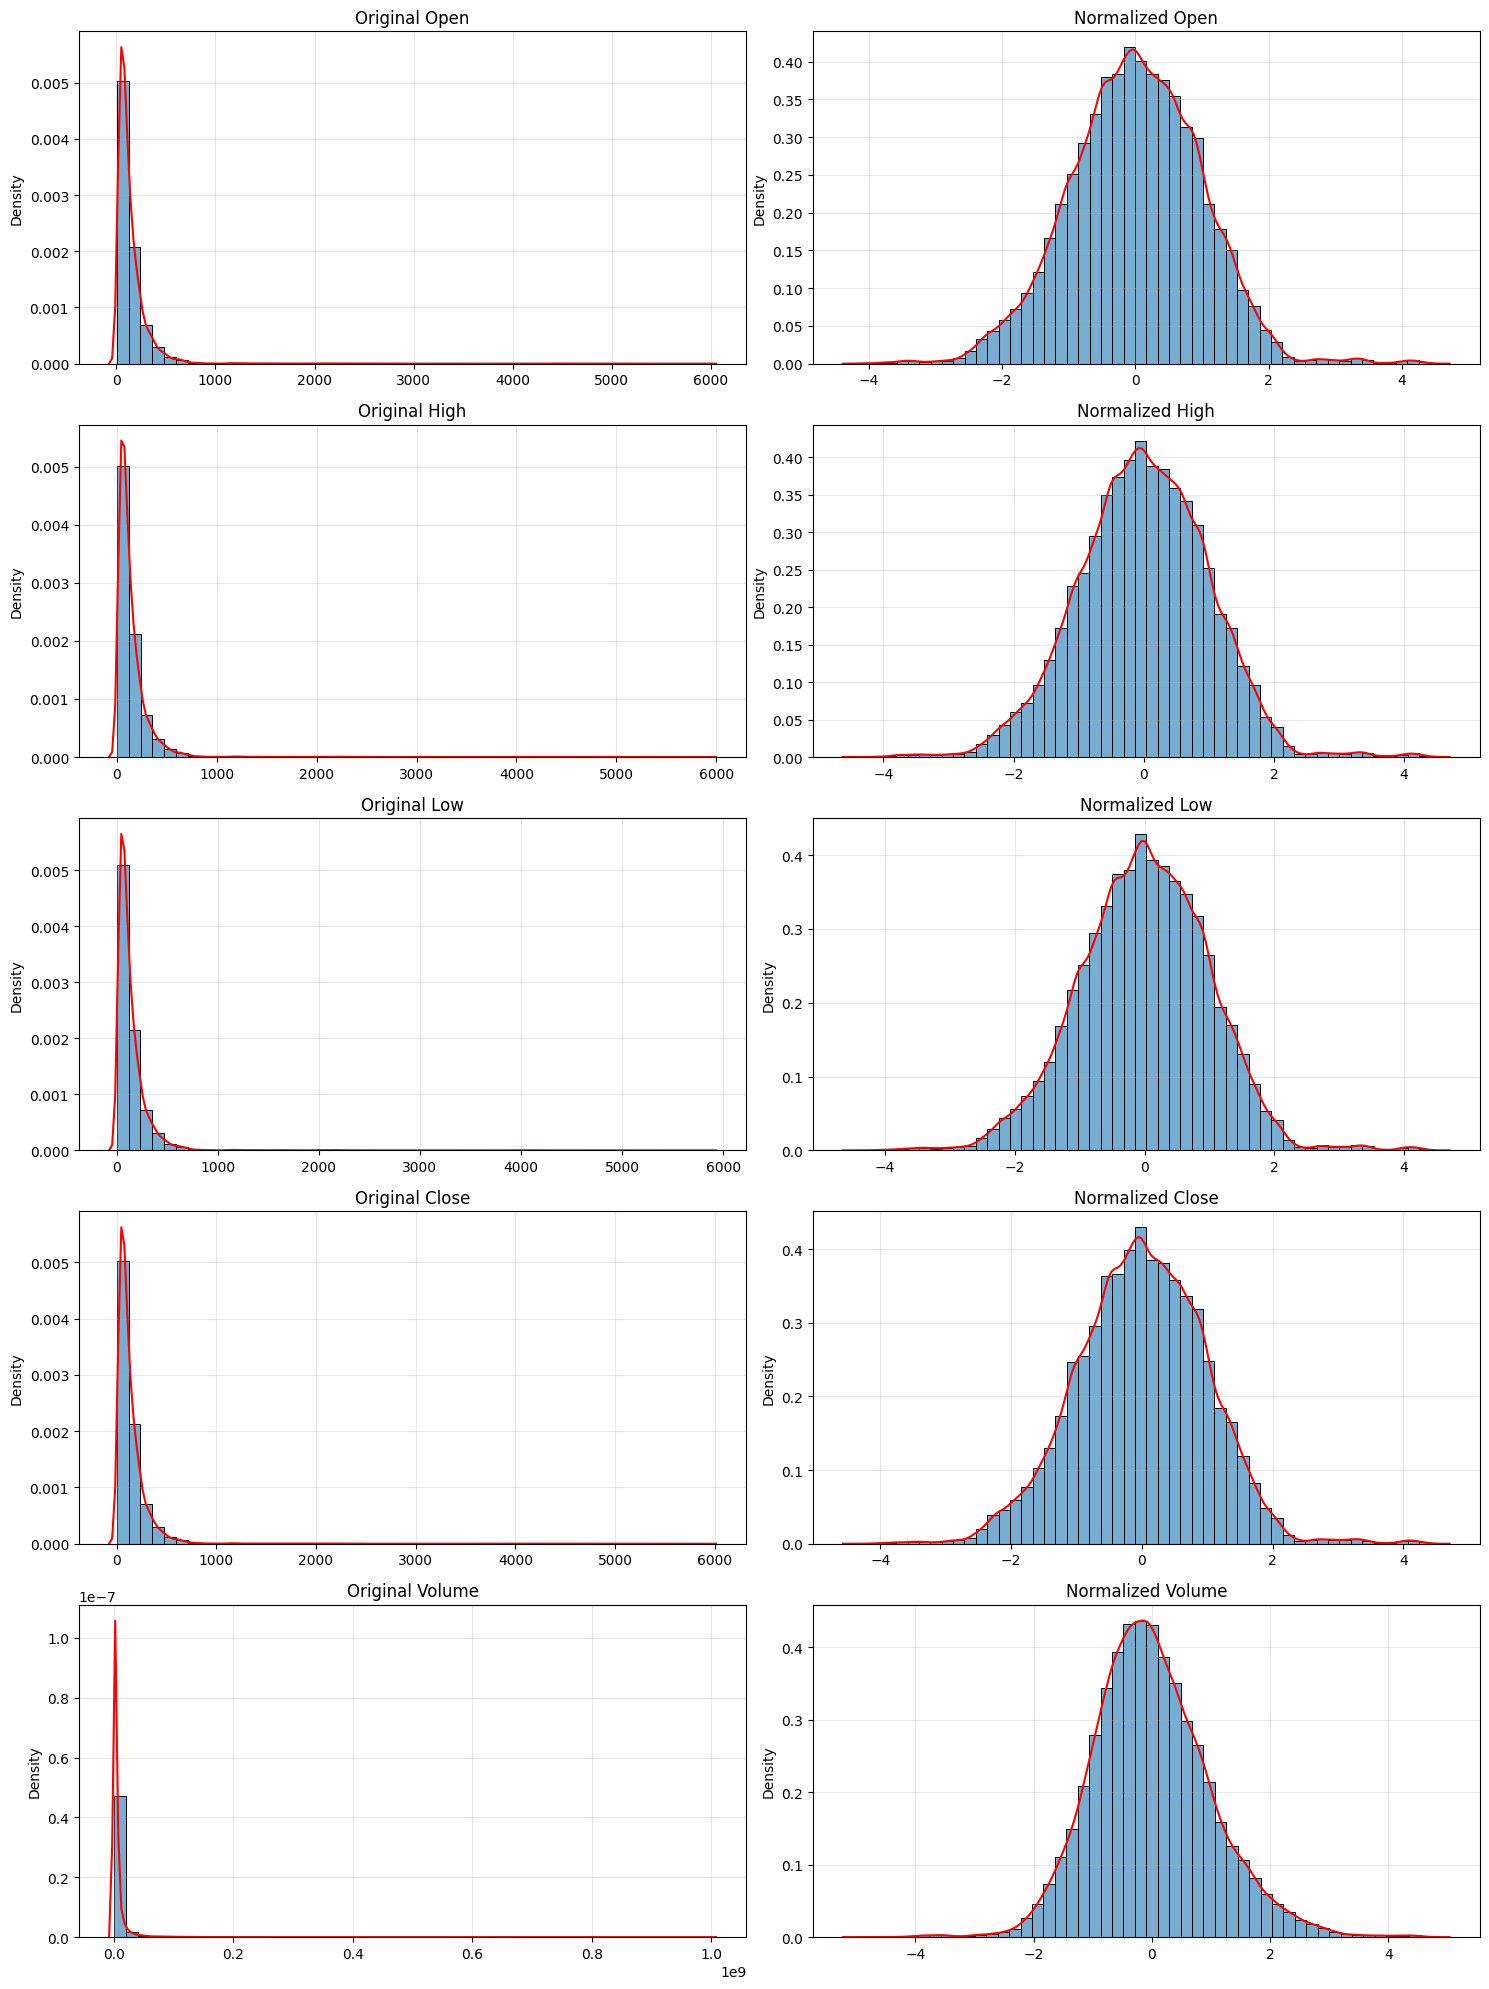


Distribution Statistics Summary:

Open:
----------------------------------------
Original:
  Range: [2.062, 5977.610]
  Mean: 150.918, Std: 254.223
  Percentiles (1%, 99%): [11.080, 718.470]

Normalized:
  Range: [-4.093, 4.420]
  Mean: 0.003, Std: 0.985
  Percentiles (1%, 99%): [-2.298, 2.158]

High:
----------------------------------------
Original:
  Range: [1.699, 5917.700]
  Mean: 152.791, Std: 260.354
  Percentiles (1%, 99%): [10.980, 724.117]

Normalized:
  Range: [-4.324, 4.403]
  Mean: -0.005, Std: 0.992
  Percentiles (1%, 99%): [-2.328, 2.155]

Low:
----------------------------------------
Original:
  Range: [1.582, 5852.400]
  Mean: 148.970, Std: 251.606
  Percentiles (1%, 99%): [10.580, 710.951]

Normalized:
  Range: [-4.351, 4.405]
  Mean: -0.000, Std: 0.991
  Percentiles (1%, 99%): [-2.326, 2.158]

Close:
----------------------------------------
Original:
  Range: [1.738, 5935.720]
  Mean: 150.288, Std: 253.193
  Percentiles (1%, 99%): [10.990, 727.490]

Normalized:
  Ra

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict
from dataclasses import dataclass
from tqdm import tqdm

@dataclass
class DistributionStats:
    min: float
    max: float
    mean: float
    std: float
    percentiles: Dict[str, float]

def fast_analyze_distributions(
    original_sequences: np.ndarray,
    normalized_sequences: np.ndarray,
    n_features: int = 5,
    batch_size: int = 5000  # Increased batch size
) -> Tuple[Dict[str, DistributionStats], Dict[str, DistributionStats]]:
    """
    High-speed distribution analysis for large sequence datasets.
    """
    print(f"Input shapes - Original: {original_sequences.shape}, Normalized: {normalized_sequences.shape}")
    
    # Pre-flatten the first two dimensions to speed up processing
    orig_flat = original_sequences.reshape(-1, original_sequences.shape[2])
    norm_flat = normalized_sequences.reshape(-1, normalized_sequences.shape[2])
    
    total_samples = len(orig_flat)
    n_features = min(n_features, original_sequences.shape[2])
    
    # Create figure
    fig, axes = plt.subplots(n_features, 2, figsize=(15, 4*n_features))
    if n_features == 1:
        axes = np.array([axes])
    plt.subplots_adjust(hspace=0.4)
    
    # Initialize stats containers
    orig_stats = {}
    norm_stats = {}
    
    feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_name = feature_names[i] if i < len(feature_names) else f'Feature_{i}'
        
        # Get random indices for sampling
        sample_indices = np.random.choice(total_samples, size=min(100000, total_samples), replace=False)
        
        # Get samples for current feature
        orig_samples = orig_flat[sample_indices, i]
        norm_samples = norm_flat[sample_indices, i]
        
        # Calculate statistics
        orig_stats[feature_name] = DistributionStats(
            min=np.min(orig_samples),
            max=np.max(orig_samples),
            mean=np.mean(orig_samples),
            std=np.std(orig_samples),
            percentiles={
                '1%': np.percentile(orig_samples, 1),
                '5%': np.percentile(orig_samples, 5),
                '95%': np.percentile(orig_samples, 95),
                '99%': np.percentile(orig_samples, 99)
            }
        )
        
        norm_stats[feature_name] = DistributionStats(
            min=np.min(norm_samples),
            max=np.max(norm_samples),
            mean=np.mean(norm_samples),
            std=np.std(norm_samples),
            percentiles={
                '1%': np.percentile(norm_samples, 1),
                '5%': np.percentile(norm_samples, 5),
                '95%': np.percentile(norm_samples, 95),
                '99%': np.percentile(norm_samples, 99)
            }
        )
        
        # Plot distributions
        sns.histplot(orig_samples, bins=50, ax=axes[i, 0], stat='density', alpha=0.6)
        sns.kdeplot(orig_samples, ax=axes[i, 0], color='red')
        axes[i, 0].set_title(f'Original {feature_name}')
        axes[i, 0].grid(True, alpha=0.3)
        
        sns.histplot(norm_samples, bins=50, ax=axes[i, 1], stat='density', alpha=0.6)
        sns.kdeplot(norm_samples, ax=axes[i, 1], color='red')
        axes[i, 1].set_title(f'Normalized {feature_name}')
        axes[i, 1].grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nDistribution Statistics Summary:")
    print("=" * 80)
    
    for feature_name in list(orig_stats.keys()):
        print(f"\n{feature_name}:")
        print("-" * 40)
        
        orig = orig_stats[feature_name]
        print("Original:")
        print(f"  Range: [{orig.min:.3f}, {orig.max:.3f}]")
        print(f"  Mean: {orig.mean:.3f}, Std: {orig.std:.3f}")
        print(f"  Percentiles (1%, 99%): [{orig.percentiles['1%']:.3f}, {orig.percentiles['99%']:.3f}]")
        
        norm = norm_stats[feature_name]
        print("\nNormalized:")
        print(f"  Range: [{norm.min:.3f}, {norm.max:.3f}]")
        print(f"  Mean: {norm.mean:.3f}, Std: {norm.std:.3f}")
        print(f"  Percentiles (1%, 99%): [{norm.percentiles['1%']:.3f}, {norm.percentiles['99%']:.3f}]")
    
    return orig_stats, norm_stats

def quick_feature_correlations(
    sequences: np.ndarray,
    n_features: int = 5,
    sample_size: int = 100000
) -> None:
    """Quick correlation analysis using sampling."""
    # Flatten and sample
    flat_data = sequences.reshape(-1, sequences.shape[2])
    if len(flat_data) > sample_size:
        indices = np.random.choice(len(flat_data), sample_size, replace=False)
        flat_data = flat_data[indices]
    
    # Calculate correlations for first n_features
    corr_matrix = np.corrcoef(flat_data[:, :n_features].T)
    
    # Plot
    plt.figure(figsize=(10, 8))
    feature_names = ['Open', 'High', 'Low', 'Close', 'Volume']
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                square=True,
                xticklabels=feature_names[:n_features],
                yticklabels=feature_names[:n_features],
                cmap='RdBu',
                center=0)
    plt.title("Feature Correlations (Sampled Data)")
    plt.tight_layout()
    plt.show()

orig_stats, norm_stats = fast_analyze_distributions(
    original_sequences=sequences,
    normalized_sequences=normalized_data,
    n_features=5  # Analyze first 5 features
)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from src.data.data_processing import denormalize
np.set_printoptions(suppress=True, precision=4)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def price_consistency_loss(sequences: torch.Tensor, weight=0.1) -> torch.Tensor:
    """Ensure OHLC relationships are valid with a softer penalty"""
    open_price, high, low, close = sequences[..., -5], sequences[..., -4], sequences[..., -3], sequences[..., -2]
    high_violation = F.relu(torch.max(open_price, close) - high) ** 2
    low_violation = F.relu(low - torch.min(open_price, close)) ** 2
    return weight * torch.mean(high_violation + low_violation)


def volatility_loss(real_sequences: torch.Tensor, generated_sequences: torch.Tensor, 
                   epoch: int, base_smoothing: float = 5e-4) -> torch.Tensor:
    """Match volatility patterns"""
    smoothing_factor = base_smoothing if epoch < 1500 else base_smoothing / 10
    # Use close price (4th last dimension)
    real_returns = torch.diff(real_sequences[..., -2], dim=1)
    gen_returns = torch.diff(generated_sequences[..., -2], dim=1)
    
    mean_volatility_loss = F.mse_loss(gen_returns.mean(dim=1), real_returns.mean(dim=1))
    variance_volatility_loss = F.mse_loss(gen_returns.std(dim=1), real_returns.std(dim=1))
    return mean_volatility_loss + variance_volatility_loss + smoothing_factor

def ticker_classification_loss(real_sequences: torch.Tensor, generated_sequences: torch.Tensor) -> torch.Tensor:
    real_tickers = real_sequences[..., :n_tickers]  # Changed from N_TICKERS
    gen_tickers = generated_sequences[..., :n_tickers]  # Changed from N_TICKERS
    return F.cross_entropy(gen_tickers.view(-1, n_tickers),
                         torch.argmax(real_tickers, dim=-1).view(-1))

def temporal_consistency_loss(sequences: torch.Tensor) -> torch.Tensor:
    """Use close price from OHLCV"""
    close_prices = sequences[..., -ohlcv_dim + 3]  # Close is 4th in OHLCV
    return torch.mean(torch.abs(torch.diff(close_prices, dim=1)))

# ====================== Helper Functions ======================
def summarize_historical_data(historical_data: torch.Tensor, window: int) -> torch.Tensor:
    return historical_data[:, -window:, :].mean(dim=1).unsqueeze(1).expand(-1, sequence_length, -1)

def gradient_penalty(disc_func, real_data: torch.Tensor, fake_data: torch.Tensor) -> torch.Tensor:
    batch_size, seq_len, feature_dim = real_data.shape
    alpha = torch.rand(batch_size, seq_len, feature_dim, requires_grad=True).to(real_data.device)
    interpolated = (alpha * real_data + (1 - alpha) * fake_data).requires_grad_(True)
    disc_interpolates, _ = disc_func(interpolated)
    gradients = torch.autograd.grad(
        outputs=disc_interpolates, inputs=interpolated,
        grad_outputs=torch.ones_like(disc_interpolates),
        create_graph=True, retain_graph=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean() * lambda_gp
    
def generate_day_encoding(sequence_length: int, batch_size: int) -> torch.Tensor:
    days = np.arange(sequence_length) % 7
    days_rad = days * (2 * np.pi / 7)
    sin_day = np.sin(days_rad)
    cos_day = np.cos(days_rad)
    sin_day_batch = np.tile(sin_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    cos_day_batch = np.tile(cos_day, (batch_size, 1)).reshape(batch_size, sequence_length, 1)
    day_encoding = np.concatenate([sin_day_batch, cos_day_batch], axis=2)
    return torch.tensor(day_encoding, dtype=torch.float32)

def denormalize(normalized_data, feature_info):
    """
    De-normalizes data based on feature statistics (mean and std).
    
    Args:
        normalized_data (np.ndarray): Normalized data with shape [batch_size, sequence_length, features].
        feature_info (dict): Dictionary with mean and std for OHLC and volume.

    Returns:
        np.ndarray: De-normalized data with same shape as input.
    """
    # Extract standard deviation and mean for OHLC and volume from feature_info
    prices_std = np.squeeze(feature_info['prices_std'])
    prices_mean = np.squeeze(feature_info['prices_mean'])
    volume_std = feature_info['volume_std']
    volume_mean = feature_info['volume_mean']

    # Ensure the input data is in the expected shape (batch_size, sequence_length, feature_dim)
    ohlc_data = normalized_data[..., :4]  # Select first 4 columns (OHLC)
    volume_data = normalized_data[..., 4]  # Select 5th column (Volume)

    # Denormalize OHLC and Volume separately
    denorm_ohlc = np.exp(ohlc_data * prices_std + prices_mean)
    denorm_volume = np.exp(volume_data * volume_std + volume_mean)

    # Reshape denorm_volume to have shape [batch_size, sequence_length, 1] for concatenation
    denorm_volume = denorm_volume[..., np.newaxis]

    # Concatenate OHLC and Volume columns to get the full denormalized data
    denorm_data = np.concatenate([denorm_ohlc, denorm_volume], axis=-1)
    return denorm_data

def diversity_loss(generated_sequences: torch.Tensor) -> torch.Tensor:
    sequence_var = torch.var(generated_sequences, dim=1)
    return torch.mean(1.0 / (sequence_var + 1e-6)) / generated_sequences.size(1)  # Normalized by sequence length


def plot_each_feature_individually(denorm_real, denorm_generated, epoch):
    columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    for i, column in enumerate(columns):
        plt.figure(figsize=(10, 5))
        plt.plot(denorm_real[:, i], label='Real', color='blue')
        plt.plot(denorm_generated[:, i], label='Generated', color='orange')
        plt.title(f"{column} - Real vs Generated (Epoch {epoch + 1})")
        plt.ylabel(column)
        plt.legend()
        plt.show()
        
def plot_pca_tsne(real_data, generated_data, epoch):
    real_flat = real_data.reshape(real_data.shape[0], -1)
    generated_flat = generated_data.reshape(generated_data.shape[0], -1)
    
    pca = PCA(n_components=2)
    real_pca = pca.fit_transform(real_flat)
    gen_pca = pca.transform(generated_flat)
    
    tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
    real_tsne = tsne.fit_transform(real_flat)
    gen_tsne = tsne.fit_transform(generated_flat)
    
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    axs[0].scatter(real_pca[:, 0], real_pca[:, 1], color='blue', alpha=0.5, label='Real')
    axs[0].scatter(gen_pca[:, 0], gen_pca[:, 1], color='orange', alpha=0.5, label='Generated')
    axs[0].set_title(f'PCA - Epoch {epoch + 1}')
    axs[0].legend()
    
    axs[1].scatter(real_tsne[:, 0], real_tsne[:, 1], color='blue', alpha=0.5, label='Real')
    axs[1].scatter(gen_tsne[:, 0], gen_tsne[:, 1], color='orange', alpha=0.5, label='Generated')
    axs[1].set_title(f't-SNE - Epoch {epoch + 1}')
    axs[1].legend()
    
    plt.show()



In [5]:
class TransformerGenerator(nn.Module):
    def __init__(self, noise_dim: int, feature_dim: int, transformer_dim: int, 
                 n_heads: int, n_layers: int):
        super(TransformerGenerator, self).__init__()
        self.input_layer = nn.Linear(noise_dim + feature_dim + 2, transformer_dim)
        
        # Separate paths for ticker, OHLC, and volume
        self.ticker_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=transformer_dim,
                nhead=n_heads,
                dim_feedforward=64,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=n_layers
        )
        
        self.ohlc_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=transformer_dim,
                nhead=n_heads,
                dim_feedforward=64,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=n_layers
        )
        
        self.volume_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=transformer_dim,
                nhead=n_heads,
                dim_feedforward=64,
                dropout=0.1,
                batch_first=True
            ),
            num_layers=n_layers
        )
        
        # Output layers for each component
        self.ticker_layer = nn.Sequential(
            nn.Linear(transformer_dim, transformer_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(transformer_dim, n_tickers),
            nn.Softmax(dim=-1)  # For one-hot encoding
        )
        
        self.ohlc_layer = nn.Sequential(
            nn.Linear(transformer_dim, transformer_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(transformer_dim, 4)
        )
        
        self.volume_layer = nn.Sequential(
            nn.Linear(transformer_dim, transformer_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(transformer_dim, 1)
        )
        
        # In Generator class (constructor or initialization function)
        mean_ohlcv = np.mean(sequences[..., -5:], axis=(0, 1))
        volume_bias = mean_ohlcv[-1]  # Volume bias
        ohlc_bias = mean_ohlcv[:-1]   # OHLC bias

        self.ohlc_layer[-1].bias.data = torch.tensor(ohlc_bias, dtype=torch.float32)
        self.volume_layer[-1].bias.data = torch.tensor([volume_bias], dtype=torch.float32)


    def forward(self, noise: torch.Tensor, day_encoding: torch.Tensor, 
                historical_data_summary: torch.Tensor) -> torch.Tensor:
        # Initial processing
        x = torch.cat([historical_data_summary, noise, day_encoding], dim=2)
        x = self.input_layer(x)
        
        # Generate components separately
        ticker_features = self.ticker_transformer(x)
        ticker_output = self.ticker_layer(ticker_features)
        
        ohlc_features = self.ohlc_transformer(x)
        ohlc_output = self.ohlc_layer(ohlc_features)
        
        volume_features = self.volume_transformer(x)
        volume_output = self.volume_layer(volume_features)
        
        # Combine all outputs
        return torch.cat([
            ticker_output,  # 494 dimensions
            day_encoding,   # 2 dimensions
            ohlc_output,    # 4 dimensions
            volume_output   # 1 dimension
        ], dim=2)

    def get_ohlcv_output(self, x: torch.Tensor) -> torch.Tensor:
        """Helper to get just OHLCV part"""
        return x[..., -ohlcv_dim:]

    
class LSTMDiscriminator(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim1_disc: int, hidden_dim2_disc: int):
        super(LSTMDiscriminator, self).__init__()
        self.input_proj = nn.Linear(feature_dim, hidden_dim1_disc)
        self.lstm = nn.LSTM(
            input_size=hidden_dim1_disc,
            hidden_size=hidden_dim2_disc,
            batch_first=True,
            bidirectional=True
        )
        self.fc_out = nn.Linear(hidden_dim2_disc * 2, 1)

    def forward(self, x: torch.Tensor, add_noise: bool = True) -> torch.Tensor:
        if add_noise:
            # Add noise only to OHLCV part
            noise_mask = torch.zeros_like(x)
            noise_mask[..., -ohlcv_dim:] = torch.randn_like(x[..., -ohlcv_dim:]) * 0.02
            x = x + noise_mask
        
        x = self.input_proj(x)  # Project full 501-dim to hidden
        lstm_out, (h_n, _) = self.lstm(x)
        features = torch.cat([h_n[0], h_n[1]], dim=1)
        output = torch.sigmoid(self.fc_out(features))
        
        return output, features

In [6]:
stock_data.keys()

dict_keys(['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'ANSS', 'AON', 'APA', 'AAPL', 'AMAT', 'APTV', 'ACGL', 'ADM', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVB', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'BK', 'BA', 'BKNG', 'BWA', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BLDR', 'BG', 'BXP', 'CHRW', 'CDNS', 'CZR', 'CPT', 'CPB', 'COF', 'CAH', 'KMX', 'CCL', 'CARR', 'CTLT', 'CAT', 'CBOE', 'CBRE', 'CDW', 'CE', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'CL', 'CMCSA', 'CAG', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CTRA', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DVA', 'D

In [7]:
def denormalize(normalized_data, feature_info):
    """
    De-normalizes data based on feature statistics (mean and std).
    
    Args:
        normalized_data (np.ndarray): Normalized data with shape [batch_size, sequence_length, features].
        feature_info (dict): Dictionary with mean and std for OHLC and volume.

    Returns:
        np.ndarray: De-normalized data with same shape as input.
    """
    # Extract standard deviation and mean for OHLC and volume from feature_info
    prices_std = np.squeeze(feature_info['prices_std'])
    prices_mean = np.squeeze(feature_info['prices_mean'])
    volume_std = feature_info['volume_std']
    volume_mean = feature_info['volume_mean']

    # Ensure the input data is in the expected shape (batch_size, sequence_length, feature_dim)
    ohlc_data = normalized_data[..., :4]  # Select first 4 columns (OHLC)
    volume_data = normalized_data[..., 4]  # Select 5th column (Volume)

    # Denormalize OHLC and Volume separately
    denorm_ohlc = np.exp(ohlc_data * prices_std + prices_mean)
    denorm_volume = np.exp(volume_data * volume_std + volume_mean)

    # Reshape denorm_volume to have shape [batch_size, sequence_length, 1] for concatenation
    denorm_volume = denorm_volume[..., np.newaxis]

    # Concatenate OHLC and Volume columns to get the full denormalized data
    denorm_data = np.concatenate([denorm_ohlc, denorm_volume], axis=-1)
    return denorm_data

# denormalize(real_sequences.detach().numpy(), feature_info)

In [ ]:
# Feature dimensions
n_tickers = 494
date_dim = 2
ohlcv_dim = 5
total_features = n_tickers + date_dim + ohlcv_dim  # 501

# Training parameters
batch_size = 16
feature_dim = total_features  # 501 total features
noise_dim = 64
transformer_dim = 64
hidden_dim1_disc = 32
hidden_dim2_disc = 32
n_heads = 1
n_layers = 1
sequence_length = normalized_data.shape[1]  # Add this line after loading normalized_data

# Loss weights
# Try reducing these weights significantly and see the effect
feature_matching_weight = 0.1
consistency_weight = 0.5
temporal_weight = 0.5
volatility_weight = 0.1
diversity_loss_weight = 0.00001
volume_weight = 1.0
ohlc_weight = 1.0

# Training hyperparameters
epochs = 200
print_interval = 20
early_stopping_patience = 20
learning_rate_gen = 0.0001
learning_rate_disc = 0.00005
lambda_gp = 1
n_critic = 2

# Setup checkpointing
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_model.pt")
best_gen_loss = float('inf')
epochs_since_improvement = 0

# Storage for sequences
stored_real_sequences = []
stored_generated_sequences = []

# ====================== Training Loop ======================
# Initialize models with correct dimensions
# Initialize
generator = TransformerGenerator(
    noise_dim=noise_dim,
    feature_dim=feature_dim,  # 501 total
    transformer_dim=transformer_dim,
    n_heads=n_heads,
    n_layers=n_layers
)

# During training, when you need OHLCV values for loss calculation:
# generated_sequences = generator(noise, day_encoding, historical_data_summary)
# ohlcv_part = generator.get_ohlcv_output(generated_sequences)

discriminator = LSTMDiscriminator(
    feature_dim=feature_dim,  # 501 total features
    hidden_dim1_disc=hidden_dim1_disc,
    hidden_dim2_disc=hidden_dim2_disc
)

# Optimizers
disc_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate_disc, betas=(0.5, 0.999))
gen_optimizer = optim.Adam(generator.parameters(), lr=learning_rate_gen, betas=(0.5, 0.999))

# Training loop
for epoch in range(epochs):
    start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
    real_sequences = torch.tensor(normalized_data[start_idx:start_idx + batch_size, :sequence_length, :], dtype=torch.float32)
    noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
    start_idx = (epoch * batch_size) % (normalized_data.shape[0] - batch_size)
    day_encoding = generate_day_encoding(sequence_length, batch_size)
    historical_data_summary = summarize_historical_data(real_sequences, sequence_length)

    # Discriminator training
    for _ in range(n_critic):
        generated_sequences = generator(noise, day_encoding, historical_data_summary)
        real_output, real_features = discriminator(real_sequences)
        fake_output, fake_features = discriminator(generated_sequences.detach())
        gp = gradient_penalty(discriminator, real_sequences, generated_sequences.detach())
        disc_loss = fake_output.mean() - real_output.mean() + gp

        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

    # Generator training
    noise = torch.randn(batch_size, sequence_length, noise_dim).to(real_sequences.device)
    generated_sequences = generator(noise, day_encoding, historical_data_summary)
    fake_output, fake_features = discriminator(generated_sequences, add_noise=False)
    _, real_features = discriminator(real_sequences, add_noise=False)

    # Split sequences for component-specific losses
    # ticker_gen = generated_sequences[..., :n_tickers]
    # ticker_real = real_sequences[..., :n_tickers]
    
    ohlc_gen = generated_sequences[..., -ohlcv_dim:-1]
    ohlc_real = real_sequences[..., -ohlcv_dim:-1]
    
    volume_gen = generated_sequences[..., -1:]
    volume_real = real_sequences[..., -1:]

    # Calculate losses
    # adversarial_loss = -fake_output.mean()
    # feature_matching_loss = F.mse_loss(fake_features, real_features.detach())
    
    # Component-specific losses
    # ticker_loss = F.cross_entropy(
    #     ticker_gen.reshape(-1, n_tickers),
    #     torch.argmax(ticker_real, dim=-1).reshape(-1)
    # )
    # ohlc_loss = F.mse_loss(ohlc_gen, ohlc_real)
    # volume_loss = F.mse_loss(volume_gen, volume_real)
    
    # Calculate losses for generator
    adversarial_loss = -fake_output.mean()  # Previously called generator loss
    feature_matching_loss_val = F.mse_loss(fake_features, real_features.detach())
    ohlc_loss = F.mse_loss(ohlc_gen, ohlc_real)
    volume_loss = F.mse_loss(volume_gen, volume_real)
    consistency_loss = price_consistency_loss(generated_sequences)
    temporal_loss = temporal_consistency_loss(generated_sequences)
    volatility_matching_loss = volatility_loss(real_sequences, generated_sequences, epoch)
    diversity_loss_val = diversity_loss(generated_sequences)

    # Total generator loss
    total_gen_loss = (
        adversarial_loss +
        feature_matching_weight * feature_matching_loss_val +
        ohlc_weight * ohlc_loss +
        volume_weight * volume_loss +
        consistency_weight * consistency_loss +
        temporal_weight * temporal_loss +
        volatility_weight * volatility_matching_loss
        # diversity_loss_weight * diversity_loss_val
    )


    gen_optimizer.zero_grad()
    total_gen_loss.backward()
    gen_optimizer.step()
    
    torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)


    # Checkpointing and visualization code remains the same as your original
    if total_gen_loss < best_gen_loss:
        best_gen_loss = total_gen_loss
        epochs_since_improvement = 0
        
        torch.save({
            'epoch': epoch + 1,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'gen_optimizer_state_dict': gen_optimizer.state_dict(),
            'disc_optimizer_state_dict': disc_optimizer.state_dict(),
            'gen_loss': total_gen_loss,
        }, checkpoint_path)
        
        # Store sequences and visualize
        stored_real_sequences.append(real_sequences.detach().cpu().numpy())
        stored_generated_sequences.append(generated_sequences.detach().cpu().numpy())
        
        # For visualization, only denormalize the OHLCV part
        # denorm_real_batch = denormalize(real_sequences.detach().cpu().numpy(), feature_info)
        # denorm_generated_batch = denormalize(generated_sequences.detach().cpu().numpy(), feature_info)
        
        # Get only OHLCV part for visualization
        # real_ohlcv = real_sequences[..., -ohlcv_dim:].detach().cpu().numpy()
        # generated_ohlcv = generated_sequences[..., -ohlcv_dim:].detach().cpu().numpy()
        
        # Denormalize only OHLCV
        # denorm_real_batch = denormalize(real_ohlcv, feature_info)
        # denorm_generated_batch = denormalize(generated_ohlcv, feature_info)
        # plt.plot(stored_real_sequences[0])
        # plot_each_feature_individually(denorm_real_batch[0], denorm_generated_batch[0], epoch)
        
        # print(f"Epoch [{epoch + 1}/{epochs}], "
        #       f"D Loss: {disc_loss.item():.4f}, "
        #       f"G Loss: {total_gen_loss.item():.4f}, "
        #       f"Consistency: {consistency_loss.item():.10f}, "  
        #       f"Volatility: {volatility_matching_loss.item():.10f}")

        # plot_each_feature_individually(denorm_real_batch[0], denorm_generated_batch[0], epoch)
        # plot_pca_tsne(real_sequences.detach().cpu().numpy(), generated_sequences.detach().cpu().numpy(), epoch)

    else:
        epochs_since_improvement += 1

    if epochs_since_improvement >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch + 1} epochs. Best generator loss: {best_gen_loss:.4f}")
        break

    if (epoch + 1) % print_interval == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], "
            f"D Loss: {disc_loss.item():.4f}, "
            f"Adversarial Loss: {adversarial_loss.item():.4f}, "
            f"Feature Matching Loss: {feature_matching_loss.item():.4f}, "
            f"OHLC Loss: {ohlc_loss.item():.4f}, "
            f"Volume Loss: {volume_loss.item():.4f}, "
            f"Consistency Loss: {consistency_loss.item():.4f}, "
            f"Temporal Loss: {temporal_loss.item():.4f}, "
            f"Volatility Loss: {volatility_matching_loss.item():.4f}, ")
            # f"Diversity Loss: {diversity_loss(generated_sequences).item():.4f}")

/Users/lucijagregov/Documents/gan_finance/.venv_finance/lib/python3.11/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


NameError: name 'feature_matching_loss' is not defined

In [ ]:
columns = ['Open', 'High', 'Low', 'Close', 'Volume']
d_real = pd.DataFrame(stored_real_sequences[0][0][:, :5], columns=columns)
d_real

,Open,High,Low,Close,Volume
0,0.483299,0.482793,0.495404,0.497566,0.487539
1,0.479236,0.474556,0.486074,0.488122,0.188641
2,0.480037,0.474861,0.490532,0.489162,0.022137
3,0.486981,0.473636,0.493433,0.484751,0.088451
4,0.485265,0.491812,0.498537,0.501382,0.276825
5,0.506590,0.492354,0.511405,0.504823,0.273381
6,0.507191,0.495903,0.513707,0.500414,0.062890
7,0.503155,0.496204,0.515037,0.503134,0.057995
8,0.503035,0.498123,0.514130,0.505846,0.319436
9,0.506048,0.493980,0.507883,0.496231,0.193525


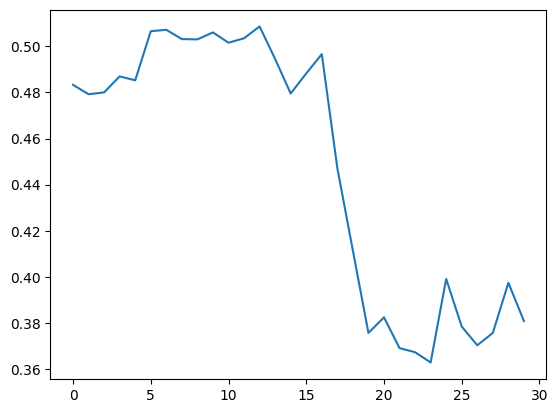

In [34]:
plt.plot(d_real.Open)

In [ ]:
columns = ['Open', 'High', 'Low', 'Close', 'Volume']
d_gen = pd.DataFrame(stored_generated_sequences[0][0][:, :5], columns=columns)
d_gen

,Open,High,Low,Close,Volume
0,0.002526,0.002045,0.002307,0.002367,0.002185
1,0.001587,0.001668,0.001995,0.001910,0.001136
2,0.002282,0.002147,0.002495,0.002436,0.001763
3,0.002479,0.002310,0.001921,0.001968,0.001774
4,0.002654,0.001740,0.001540,0.001942,0.001239
5,0.001904,0.001714,0.002368,0.001865,0.001610
6,0.001459,0.001701,0.001301,0.001720,0.001291
7,0.001566,0.001527,0.002032,0.002186,0.001501
8,0.001385,0.001769,0.002514,0.001471,0.002190
9,0.001860,0.002349,0.001823,0.002329,0.001945


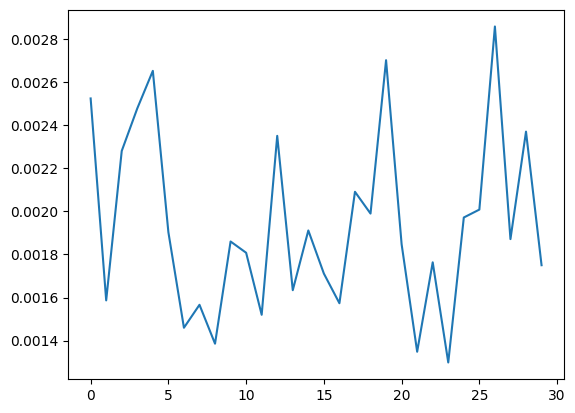

In [36]:
plt.plot(d_gen.Open)

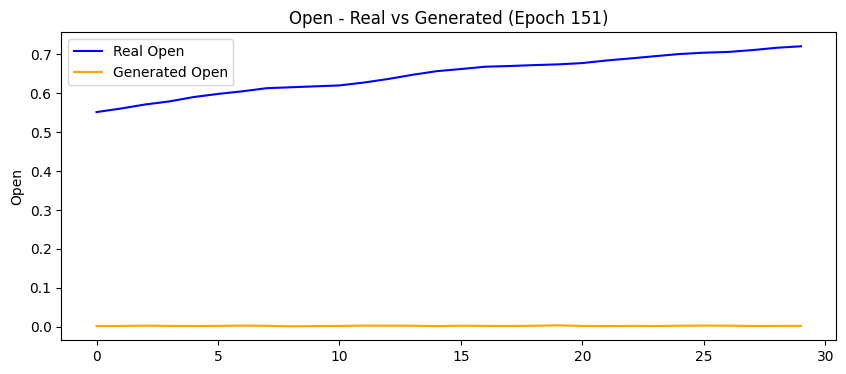

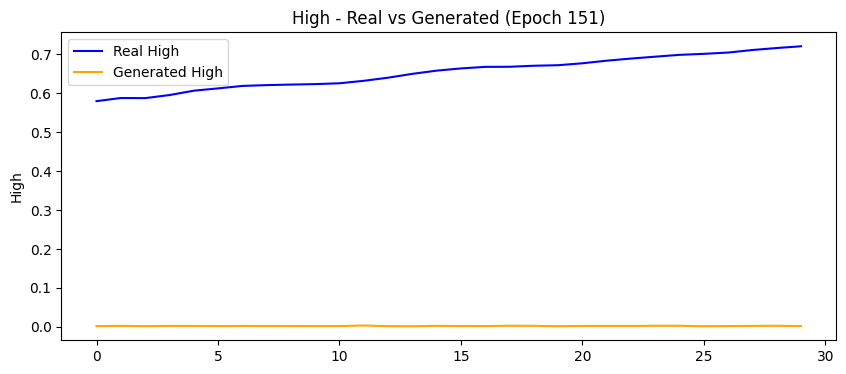

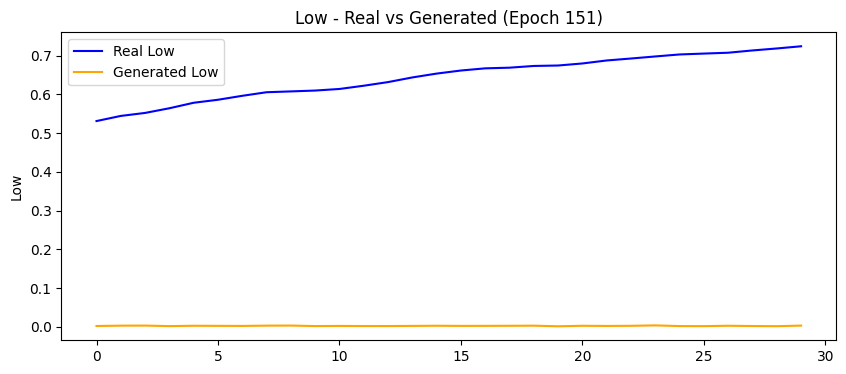

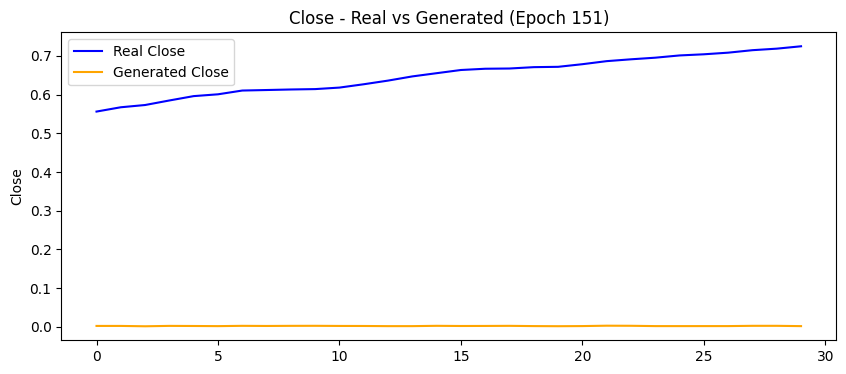

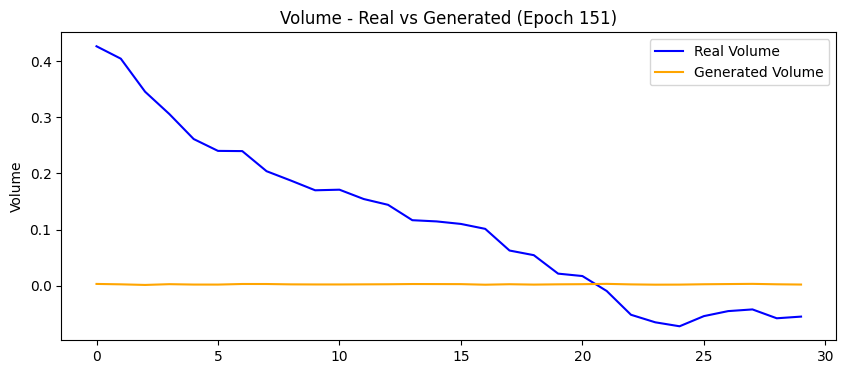

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Feature names for reference
columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Select a specific epoch to compare, e.g., epoch 0
epoch_to_compare = 150

# Convert to NumPy arrays for easier manipulation if not already arrays
real_sequences_epoch = np.array(stored_real_sequences[epoch_to_compare])
generated_sequences_epoch = np.array(stored_generated_sequences[epoch_to_compare])

# Compute mean or median along the batch dimension (axis=0) for each time step
real_sequence_mean = np.mean(real_sequences_epoch, axis=0)
generated_sequence_mean = np.mean(generated_sequences_epoch, axis=0)

# Alternatively, compute median by replacing `np.mean` with `np.median`:
# real_sequence_mean = np.median(real_sequences_epoch, axis=0)
# generated_sequence_mean = np.median(generated_sequences_epoch, axis=0)

# Convert to DataFrames for easier plotting and labeling
real_df = pd.DataFrame(real_sequence_mean[:, :5], columns=columns)
generated_df = pd.DataFrame(generated_sequence_mean[:, :5], columns=columns)

# Plot each feature individually
for feature in columns:
    plt.figure(figsize=(10, 4))
    plt.plot(real_df[feature], label=f'Real {feature}', color='blue')
    plt.plot(generated_df[feature], label=f'Generated {feature}', color='orange')
    plt.title(f"{feature} - Real vs Generated (Epoch {epoch_to_compare + 1})")
    plt.ylabel(feature)
    plt.legend()
    plt.show()
